In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

from experiment import get_device, set_seeds, make_loaders
from models.gbm import simulate_gbm
from derivatives.european_call import black_scholes_call, black_scholes_delta
from strategies.delta_hedge import run_delta_hedge
from strategies.neural_hedge import NeuralHedge
from portfolio import run_hedge_torch, build_state
from train import fit, collect_pnl, collect_results
from metrics import hedge_metrics
from losses import MSEHedgingLoss

In [7]:
SEED = 123

set_seeds(SEED)
device = get_device()
DTYPE = torch.float32

print("device:", device)

device: mps


In [4]:
# experiment params

S0 = 100.0
K = 100.0

sigma = 0.20

r = 0.0
T = 1.0

n_steps = 52


# training params

n_train = 50_000
n_val = 10_000
n_test = 50_000

batch_size = 1024

n_epochs = 50

learning_rate = 1e-3

In [5]:
# 0, 5, 10, 20, 100 bps
cost_rates = [0.0, 0.0005, 0.0010, 0.0020, 0.0100]

In [6]:
train_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_train,
    r=r,
    seed=123,
).spot

val_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_val,
    r=r,
    seed=456,
).spot

test_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_test,
    r=r,
    seed=789,
).spot

train_spot = torch.tensor(train_paths_np, dtype=DTYPE)
val_spot = torch.tensor(val_paths_np, dtype=DTYPE)
test_spot = torch.tensor(test_paths_np, dtype=DTYPE)

train_dataset = TensorDataset(train_spot)
val_dataset = TensorDataset(val_spot)
test_dataset = TensorDataset(test_spot)

print(train_paths_np.shape)
print(val_paths_np.shape)
print(test_paths_np.shape)

(50000, 53)
(10000, 53)
(50000, 53)


In [8]:
premium = black_scholes_call(
    S=S0,
    K=K,
    sigma=sigma,
    T=T,
    t=0.0,
    r=r,
)

print("initial call premium:", premium)

initial call premium: 7.965567455405804


In [9]:
def make_run_batch(transaction_cost_rate):
    def run_batch(model, batch):
        (spot_paths,) = batch

        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = torch.full_like(spot_paths, sigma**2)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=variance_paths,
            K=K,
            T=T,
            premium=premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate,
        )

        return result["pnl"]

    return run_batch


In [10]:
def make_model():
    torch.manual_seed(MODEL_SEED)
    model = NeuralHedge(hidden_dim=64)

    return model.to(device)

In [9]:
trained_models = {}
training_histories = {}

for c in cost_rates:
    print(f"\ntraining c = {c:.4%}")

    train_loader, val_loader, _ = make_loaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=batch_size,
        seed=SEED,
    )
    
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    run_batch = make_run_batch(transaction_cost_rate=c)

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=MSEHedgingLoss(),
        run_batch=run_batch,
        n_epochs=n_epochs,
    )

    trained_models[c] = model
    training_histories[c] = pd.DataFrame(history)


NameError: name 'cost_rates' is not defined

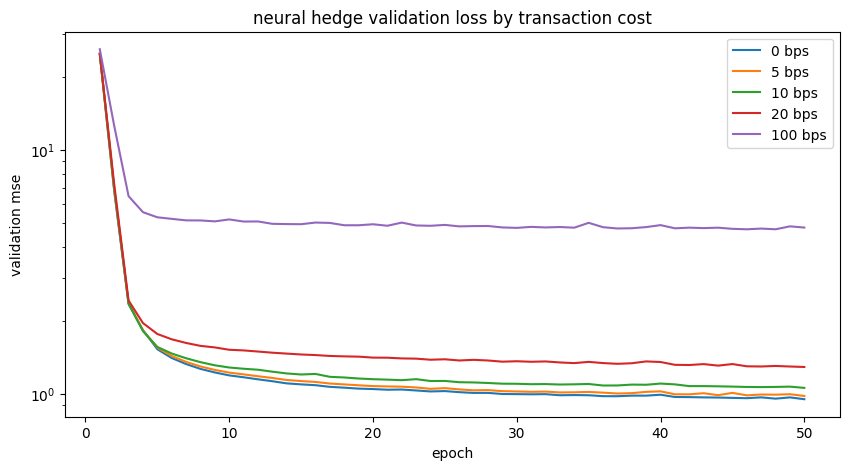

In [12]:
plt.figure(figsize=(10, 5))

for c in cost_rates:
    history = training_histories[c]

    plt.plot(
        history["epoch"],
        history["val_loss"],
        label=f"{c * 10_000:.0f} bps",
    )

plt.yscale("log")

plt.xlabel("epoch")
plt.ylabel("validation mse")
plt.title("neural hedge validation loss by transaction cost")

plt.legend()
plt.show()

In [13]:
def evaluate_policy(
    model,
    loader,
    transaction_cost_rate,
):
    def run_batch(model, batch):
        (spot_paths,) = batch
        spot_paths = spot_paths.to(device=device, dtype=DTYPE)

        # gbm has constant variance
        variance_paths = torch.full_like(spot_paths, sigma**2)

        return run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=variance_paths,
            K=K,
            T=T,
            premium=premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate,
        )

    return collect_results(model, loader, run_batch)

In [ ]:
_, _, test_loader = make_loaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=batch_size,
        seed=SEED,
    )

test_results = {}

for c in cost_rates:
    test_results[c] = evaluate_policy(
        model=trained_models[c],
        loader=test_loader,
        transaction_cost_rate=c,
    )

In [15]:
bs_results = {}

for c in cost_rates:
    result = run_delta_hedge(
        stock_paths=test_paths_np,
        K=K,
        sigma=sigma,
        T=T,
        r=r,
        transaction_cost_rate=c,
        record_history=False,
    )

    bs_results[c] = result

In [16]:
records = []

for c in cost_rates:
    nn_metrics = hedge_metrics(test_results[c])

    records.append({
        "strategy": "neural",
        "cost_rate": c,
        "cost_bps": c * 10_000,
        **nn_metrics,
    })

    bs_metrics = hedge_metrics(bs_results[c])

    records.append({
        "strategy": "black-scholes delta",
        "cost_rate": c,
        "cost_bps": c * 10_000,
        **bs_metrics,
    })

results_df = pd.DataFrame(records)

results_df

,strategy,cost_rate,cost_bps,mean_pnl,std_pnl,rmse,q05,q01,cvar95_loss,cvar99_loss,mean_tc,mean_share_turnover,mean_notional_turnover
0,neural,0.0000,0.0,0.003130,0.979398,0.979393,-1.606773,-2.659002,2.259696,3.272061,0.000000,2.854724,284.440002
1,black-scholes delta,0.0000,0.0,0.000034,0.951395,0.951385,-1.552763,-2.599678,2.208921,3.265699,0.000000,2.805728,279.718147
2,neural,0.0005,5.0,-0.138790,0.981749,0.991501,-1.761328,-2.794893,2.407865,3.420631,0.140429,2.818987,280.858445
3,black-scholes delta,0.0005,5.0,-0.139825,0.957243,0.967392,-1.726075,-2.797864,2.399025,3.476145,0.139859,2.805728,279.718147
4,neural,0.0010,10.0,-0.269580,0.989728,1.025776,-1.892768,-2.946133,2.540322,3.565465,0.270821,2.716382,270.821312
5,black-scholes delta,0.0010,10.0,-0.279684,0.964852,1.004561,-1.905235,-3.000344,2.590873,3.687631,0.279718,2.805728,279.718147
6,neural,0.0020,20.0,-0.501519,1.012492,1.129885,-2.164515,-3.241750,2.821163,3.885623,0.502957,2.522882,251.478464
7,black-scholes delta,0.0020,20.0,-0.559403,0.985176,1.132910,-2.265979,-3.414331,2.979086,4.113930,0.559436,2.805728,279.718147
8,neural,0.0100,100.0,-1.568010,1.474222,2.152195,-4.052336,-5.427166,4.909874,6.282201,1.568863,1.574006,156.886293
9,black-scholes delta,0.0100,100.0,-2.797148,1.336468,3.100024,-5.306980,-6.764966,6.221531,7.620638,2.797181,2.805728,279.718147


In [17]:
for c in cost_rates:
    if c == 0:
        continue

    result = test_results[c]

    implied_costs = c * result["notional_turnover"]

    np.testing.assert_allclose(
        result["transaction_costs"],
        implied_costs,
        rtol=1e-5,
        atol=1e-6,
    )

for c in cost_rates:
    if c == 0:
        continue

    result = bs_results[c]

    implied_costs = c * result["notional_turnover"]

    np.testing.assert_allclose(
        result["transaction_costs"],
        implied_costs,
        rtol=1e-5,
        atol=1e-6,
    )

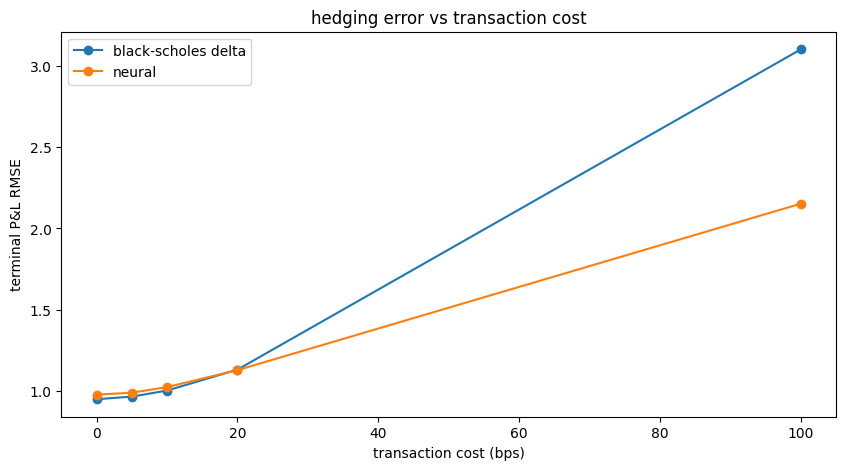

In [18]:
plt.figure(figsize=(10, 5))

for strategy in ["black-scholes delta", "neural"]:
    subset = results_df[results_df["strategy"] == strategy]

    plt.plot(
        subset["cost_bps"],
        subset["rmse"],
        marker="o",
        label=strategy,
    )

plt.xlabel("transaction cost (bps)")
plt.ylabel("terminal P&L RMSE")
plt.title("hedging error vs transaction cost")

plt.legend()
plt.show()

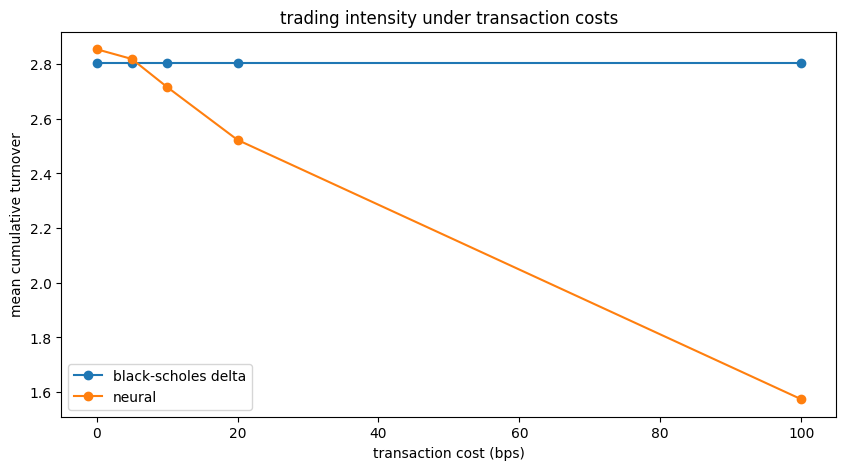

In [19]:
plt.figure(figsize=(10, 5))

for strategy in ["black-scholes delta", "neural"]:
    subset = results_df[results_df["strategy"] == strategy]

    plt.plot(
        subset["cost_bps"],
        subset["mean_share_turnover"],
        marker="o",
        label=strategy,
    )

plt.xlabel("transaction cost (bps)")
plt.ylabel("mean cumulative turnover")
plt.title("trading intensity under transaction costs")

plt.legend()
plt.show()

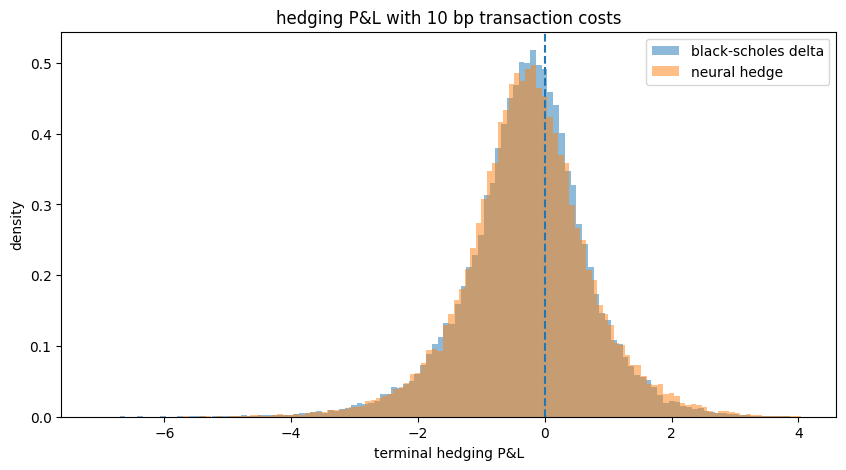

In [20]:
c_plot = 0.0010

nn_pnl = test_results[c_plot]["pnl"]
bs_pnl = bs_results[c_plot]["pnl"]

plt.figure(figsize=(10, 5))

plt.hist(
    bs_pnl,
    bins=120,
    density=True,
    alpha=0.5,
    label="black-scholes delta"
)

plt.hist(
    nn_pnl,
    bins=120,
    density=True,
    alpha=0.5,
    label="neural hedge"
)

plt.axvline(0.0, linestyle="--")

plt.xlabel("terminal hedging P&L")
plt.ylabel("density")
plt.title("hedging P&L with 10 bp transaction costs")

plt.legend()
plt.show()

In [21]:
previous_grid = torch.linspace(0.0, 1.0, 300, device=device)

S_eval = 100.0
t_eval = 0.5

In [22]:
def policy_vs_inventory(model):
    with torch.no_grad():
        state = build_state(
            S=torch.full_like(previous_grid, S_eval),
            v=sigma**2,
            t=t_eval,
            shares=previous_grid,
            K=K,
            T=T,
        )

        target = model(state)

    return target.cpu().numpy()

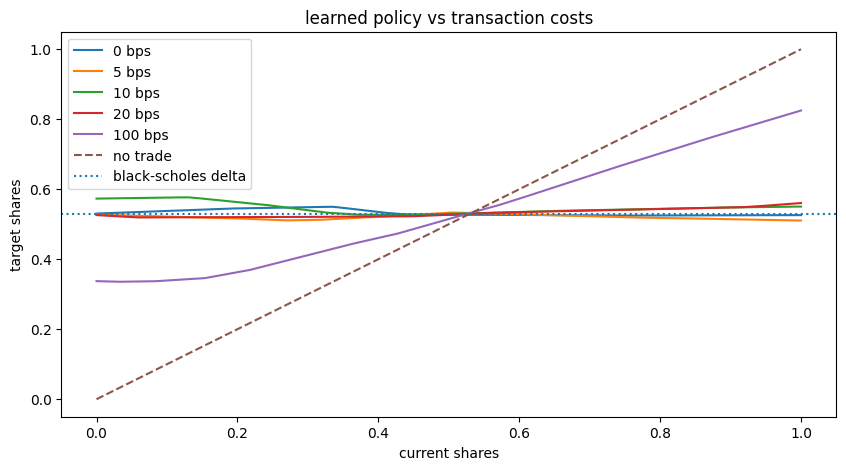

In [23]:
previous_np = previous_grid.cpu().numpy()

bs_target = black_scholes_delta(
    S=S_eval,
    K=K,
    sigma=sigma,
    T=T,
    t=t_eval,
    r=r,
)

plt.figure(figsize=(10, 5))

for c in cost_rates:
    target = policy_vs_inventory(trained_models[c])

    plt.plot(
        previous_np,
        target,
        label=f"{c * 10_000:.0f} bps"
    )

plt.plot(
    previous_np,
    previous_np,
    linestyle="--",
    label="no trade",
)

plt.axhline(
    bs_target,
    linestyle=":",
    label="black-scholes delta",
)

plt.xlabel("current shares")
plt.ylabel("target shares")
plt.title("learned policy vs transaction costs")

plt.legend()
plt.show()